In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('parkinson_disease.csv')
pd.set_option('display.max_columns', 10)
df



,id,gender,PPE,DFA,RPDE,...,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,...,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,...,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,...,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,...,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,...,11.6891,8.2103,5.0559,6.1164,1
...,...,...,...,...,...,...,...,...,...,...,...
751,250,0,0.80903,0.56355,0.28385,...,3.5400,3.3805,3.2003,6.8671,0
752,250,0,0.16084,0.56499,0.59194,...,4.2616,6.3042,10.9058,28.4170,0
753,251,0,0.88389,0.72335,0.46815,...,2.5361,3.5377,3.3545,5.0424,0
754,251,0,0.83782,0.74890,0.49823,...,1.9664,2.6801,2.8332,3.7131,0


In [111]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 755 entries, id to class
dtypes: float64(749), int64(6)
memory usage: 4.4 MB


(756, 755)

In [113]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,756.0,125.500000,72.793721,0.000000,62.750000,125.500000,188.250000,251.00000
gender,756.0,0.515873,0.500079,0.000000,0.000000,1.000000,1.000000,1.00000
PPE,756.0,0.746284,0.169294,0.041551,0.762833,0.809655,0.834315,0.90766
DFA,756.0,0.700414,0.069718,0.543500,0.647053,0.700525,0.754985,0.85264
RPDE,756.0,0.489058,0.137442,0.154300,0.386537,0.484355,0.586515,0.87123
...,...,...,...,...,...,...,...,...
tqwt_kurtosisValue_dec_33,756.0,12.375335,16.341665,1.628700,3.114375,4.741450,12.201325,73.53220
tqwt_kurtosisValue_dec_34,756.0,14.799230,15.722502,1.861700,3.665925,6.725700,21.922050,62.00730
tqwt_kurtosisValue_dec_35,756.0,14.751559,14.432979,1.955900,3.741275,7.334250,22.495175,57.54430
tqwt_kurtosisValue_dec_36,756.0,31.481110,34.230991,2.364000,3.948750,10.637250,61.125325,156.42370


In [115]:
df.isnull().sum().sum()

0

In [119]:
print(df['class'].value_counts())
print(df['class'].value_counts(normalize=True))  
print(df['class'].isnull().sum())


class
1    564
0    192
Name: count, dtype: int64
class
1    0.746032
0    0.253968
Name: proportion, dtype: float64
0


# From the analysis above we can conclude that there are no null or missing values.

# We can clearly see that there is a class imbalance 
564 cases have Parkinson
192 are healthy

We will do a class balancing later

## We can also notice that the dataset contains 3 observations for each patient, we must aggregate this data using the id.
So let's start with that


In [121]:
df = df.groupby('id').mean().reset_index() 
df.drop('id', axis=1, inplace=True)

In [123]:
df

,gender,PPE,DFA,RPDE,numPulses,...,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,1.0,0.823387,0.696370,0.567250,235.333333,...,6.259100,4.021533,4.164333,22.961700,1.0
1,0.0,0.415637,0.793993,0.592453,213.333333,...,7.933133,5.490533,4.941833,4.467233,1.0
2,1.0,0.801973,0.619967,0.520563,319.333333,...,4.772067,9.176633,11.848100,5.552367,1.0
3,0.0,0.828707,0.626097,0.537183,493.000000,...,3.085267,3.184433,4.032933,22.773633,1.0
4,0.0,0.831287,0.779397,0.726717,362.666667,...,2.811367,7.268333,13.338833,63.766900,1.0
...,...,...,...,...,...,...,...,...,...,...,...
247,0.0,0.751703,0.651830,0.586847,326.000000,...,20.532267,17.000400,16.132633,40.472133,1.0
248,1.0,0.611750,0.688327,0.452343,356.666667,...,3.071367,3.957200,4.962500,2.890800,1.0
249,1.0,0.819857,0.788800,0.373520,339.666667,...,11.885633,16.674300,14.303767,11.819967,1.0
250,0.0,0.600530,0.569010,0.411987,402.333333,...,3.421233,4.149200,5.726533,13.467700,0.0


In [125]:
print(df['class'].value_counts())
print(df['class'].value_counts(normalize=True))


class
1.0    188
0.0     64
Name: count, dtype: int64
class
1.0    0.746032
0.0    0.253968
Name: proportion, dtype: float64


In [127]:
df.corr()

,gender,PPE,DFA,RPDE,numPulses,...,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
gender,1.000000,0.014374,0.104643,0.182123,-0.509785,...,0.131868,0.163985,0.135109,0.121971,0.182713
PPE,0.014374,1.000000,-0.113344,-0.474091,0.213316,...,0.059702,0.081546,0.077205,0.075091,-0.103041
DFA,0.104643,-0.113344,1.000000,0.171102,-0.296987,...,-0.030422,0.066398,0.096407,0.144736,0.322357
RPDE,0.182123,-0.474091,0.171102,1.000000,-0.556395,...,-0.109201,-0.039366,-0.019258,0.037335,0.267733
numPulses,-0.509785,0.213316,-0.296987,-0.556395,1.000000,...,-0.079303,-0.101547,-0.095644,-0.080576,-0.302712
...,...,...,...,...,...,...,...,...,...,...,...
tqwt_kurtosisValue_dec_33,0.131868,0.059702,-0.030422,-0.109201,-0.079303,...,1.000000,0.812157,0.668839,0.520094,0.146804
tqwt_kurtosisValue_dec_34,0.163985,0.081546,0.066398,-0.039366,-0.101547,...,0.812157,1.000000,0.953832,0.801711,0.244632
tqwt_kurtosisValue_dec_35,0.135109,0.077205,0.096407,-0.019258,-0.095644,...,0.668839,0.953832,1.000000,0.887037,0.275216
tqwt_kurtosisValue_dec_36,0.121971,0.075091,0.144736,0.037335,-0.080576,...,0.520094,0.801711,0.887037,1.000000,0.325589


# Checking for multicollinearity in the data 
#### It can negatively impact machine learning models by making them unstable and less interpretable.

### To resolve this we need to identify and remove highly correlated features from our dataset using Pearson Correlation Coefficient.
#### PCC is used for measuring the strength and direction of a linear relationship between two variables.
#### Here we consider that a feature is highly correlated if the correlation > 0.7.
#### The column "class" is excluded since it's the target column (the one that indicates if a person has the disease or not)

In [133]:
columns = list(df.columns)
print("Number of columns : ", len(columns))

Number of columns :  754


In [135]:
columns = list(df.columns)
for col in columns:
    if col == 'class':
        continue

    filtered_columns = [col]
    for col1 in df.columns:
        if((col == col1) | (col == 'class')):
            continue

        val = df[col].corr(df[col1])
        if val > 0.7:
            # If the correlation between the two features is more than 0.7, remove it
            columns.remove(col1)
            continue
        else:
            filtered_columns.append(col1)
            
    df = df[filtered_columns]
df.shape

(252, 287)

In [139]:
df


,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_26,tqwt_kurtosisValue_dec_25,...,RPDE,DFA,PPE,gender,class
0,4.021533,12.293333,1.561733,1.591700,2.437633,...,0.567250,0.696370,0.823387,1.0,1.0
1,5.490533,6.117633,4.918567,1.881900,1.831233,...,0.592453,0.793993,0.415637,0.0,1.0
2,9.176633,14.584467,41.129400,1.590333,1.577067,...,0.520563,0.619967,0.801973,1.0,1.0
3,3.184433,2.842167,1.677633,5.676767,4.138300,...,0.537183,0.626097,0.828707,0.0,1.0
4,7.268333,2.953200,4.104600,3.614567,3.384267,...,0.726717,0.779397,0.831287,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
247,17.000400,13.479700,19.298667,1.552700,1.541600,...,0.586847,0.651830,0.751703,0.0,1.0
248,3.957200,2.880233,4.448533,1.852067,1.993367,...,0.452343,0.688327,0.611750,1.0,1.0
249,16.674300,29.098533,90.482767,1.635000,1.598967,...,0.373520,0.788800,0.819857,1.0,1.0
250,4.149200,2.706000,2.674667,11.502200,2.268800,...,0.411987,0.569010,0.600530,0.0,0.0


In [141]:
df.corr()

,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_26,tqwt_kurtosisValue_dec_25,...,RPDE,DFA,PPE,gender,class
tqwt_kurtosisValue_dec_34,1.000000,0.595167,0.077339,-0.091217,-0.057727,...,-0.039366,0.066398,0.081546,0.163985,0.244632
tqwt_kurtosisValue_dec_30,0.595167,1.000000,0.545463,0.214494,0.174307,...,-0.177054,-0.064156,0.134644,0.084258,-0.087569
tqwt_kurtosisValue_dec_28,0.077339,0.545463,1.000000,0.461981,0.305918,...,-0.385035,-0.171115,0.230616,-0.117443,-0.321180
tqwt_kurtosisValue_dec_26,-0.091217,0.214494,0.461981,1.000000,0.575614,...,-0.316551,-0.281183,0.120572,-0.282943,-0.394855
tqwt_kurtosisValue_dec_25,-0.057727,0.174307,0.305918,0.575614,1.000000,...,-0.213117,-0.202777,0.019165,-0.062228,-0.208101
...,...,...,...,...,...,...,...,...,...,...,...
RPDE,-0.039366,-0.177054,-0.385035,-0.316551,-0.213117,...,1.000000,0.171102,-0.474091,0.182123,0.267733
DFA,0.066398,-0.064156,-0.171115,-0.281183,-0.202777,...,0.171102,1.000000,-0.113344,0.104643,0.322357
PPE,0.081546,0.134644,0.230616,0.120572,0.019165,...,-0.474091,-0.113344,1.000000,0.014374,-0.103041
gender,0.163985,0.084258,-0.117443,-0.282943,-0.062228,...,0.182123,0.104643,0.014374,1.000000,0.182713


### Even with all of this, we are still left with about 300 columns.
#### We need to apply feature selection, to retain only the most relevant features, we can use the "Chi-Square Method".
#### Basicaly, its checks if a feature is significantly associated with the target variable? If yes => keep it else => removes it.

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Columns: 287 entries, tqwt_kurtosisValue_dec_34 to class
dtypes: float64(287)
memory usage: 565.2 KB


In [145]:
X = df.drop('class', axis=1)
X_norm = MinMaxScaler().fit_transform(X)
selector = SelectKBest(chi2, k=30)
selector.fit(X_norm, df['class'])
filtered_columns = selector.get_support()
filtered_data = X.loc[:, filtered_columns]
filtered_data['class'] = df['class']
df = filtered_data
df.shape

(252, 31)

In [147]:
df

,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_26,tqwt_kurtosisValue_dec_25,tqwt_maxValue_dec_1,...,VFER_mean,f1,DFA,gender,class
0,4.021533,1.561733,1.591700,2.437633,0.023362,...,0.000479,550.716984,0.696370,1.0,1.0
1,5.490533,4.918567,1.881900,1.831233,0.092748,...,0.000253,832.920994,0.793993,0.0,1.0
2,9.176633,41.129400,1.590333,1.577067,0.037454,...,0.001704,683.269240,0.619967,1.0,1.0
3,3.184433,1.677633,5.676767,4.138300,0.028221,...,0.003726,712.242460,0.626097,0.0,1.0
4,7.268333,4.104600,3.614567,3.384267,0.015097,...,0.001358,504.376144,0.779397,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
247,17.000400,19.298667,1.552700,1.541600,0.013951,...,0.001110,705.192316,0.651830,0.0,1.0
248,3.957200,4.448533,1.852067,1.993367,0.022423,...,0.000921,654.991006,0.688327,1.0,1.0
249,16.674300,90.482767,1.635000,1.598967,0.081714,...,0.000107,443.565702,0.788800,1.0,1.0
250,4.149200,2.674667,11.502200,2.268800,0.072059,...,0.008256,907.148124,0.569010,0.0,0.0


In [149]:

selected_feature_names = X.columns[selector.get_support()]
print("Selected features:", selected_feature_names.tolist())


Selected features: ['tqwt_kurtosisValue_dec_34', 'tqwt_kurtosisValue_dec_28', 'tqwt_kurtosisValue_dec_26', 'tqwt_kurtosisValue_dec_25', 'tqwt_maxValue_dec_1', 'tqwt_minValue_dec_12', 'tqwt_TKEO_mean_dec_32', 'tqwt_TKEO_mean_dec_13', 'tqwt_entropy_log_dec_26', 'tqwt_entropy_shannon_dec_35', 'tqwt_entropy_shannon_dec_17', 'tqwt_entropy_shannon_dec_11', 'tqwt_entropy_shannon_dec_9', 'tqwt_energy_dec_33', 'tqwt_energy_dec_31', 'tqwt_energy_dec_28', 'tqwt_energy_dec_27', 'tqwt_energy_dec_26', 'tqwt_energy_dec_25', 'tqwt_energy_dec_16', 'tqwt_energy_dec_14', 'tqwt_energy_dec_12', 'tqwt_energy_dec_7', 'std_MFCC_8th_coef', 'mean_MFCC_2nd_coef', 'IMF_SNR_SEO', 'VFER_mean', 'f1', 'DFA', 'gender']


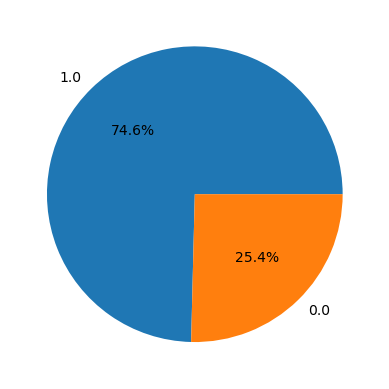

In [151]:

x = df['class'].value_counts()
plt.pie(x.values,
        labels = x.index,
        autopct='%1.1f%%')
plt.show()

# We can clearly see that there is an imbalance between the two classes
We need to address this issue because it is crutial to avoid model bias

In [ ]:
features = df.drop('class', axis=1)

features = df.drop('class', axis=1)
target = df['class']


X_train, X_val, y_train, y_val = train_test_split(features, target,
                                                  test_size=0.2,
                                                  random_state=10)

ros = RandomOverSampler(sampling_strategy=1.0, random_state=0)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

X_resampled.shape, y_resampled.value_counts()

((302, 30),
 class
 1.0    151
 0.0    151
 Name: count, dtype: int64)

RandomForestClassifier :
Training Accuracy: 1.0
Training ROC AUC: 1.0
Training Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       151
         1.0       1.00      1.00      1.00       151

    accuracy                           1.00       302
   macro avg       1.00      1.00      1.00       302
weighted avg       1.00      1.00      1.00       302

Validation Accuracy: 0.8431372549019608
Validation ROC AUC: 0.8156370656370657
Validation Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      0.57      0.67        14
         1.0       0.85      0.95      0.90        37

    accuracy                           0.84        51
   macro avg       0.83      0.76      0.78        51
weighted avg       0.84      0.84      0.83        51



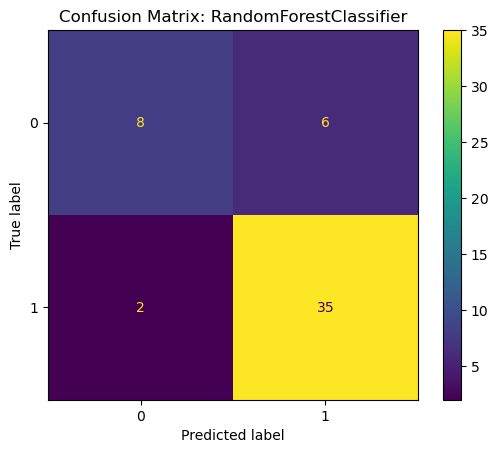


SVC :
Training Accuracy: 0.6258278145695364
Training ROC AUC: 0.7104074382702513
Training Classification Report:
               precision    recall  f1-score   support

         0.0       0.66      0.52      0.58       151
         1.0       0.60      0.73      0.66       151

    accuracy                           0.63       302
   macro avg       0.63      0.63      0.62       302
weighted avg       0.63      0.63      0.62       302

Validation Accuracy: 0.6470588235294118
Validation ROC AUC: 0.7586872586872587
Validation Classification Report:
               precision    recall  f1-score   support

         0.0       0.41      0.64      0.50        14
         1.0       0.83      0.65      0.73        37

    accuracy                           0.65        51
   macro avg       0.62      0.65      0.61        51
weighted avg       0.71      0.65      0.66        51



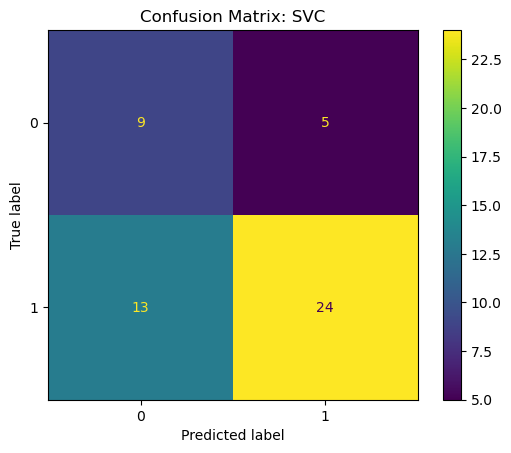

In [ ]:
models = [
    RandomForestClassifier(class_weight='balanced', random_state=42),
    SVC(kernel='rbf', probability=True, class_weight='balanced')
]

for model in models:
    model.fit(X_resampled, y_resampled)
    print(f'{model.__class__.__name__} :')

    train_preds = model.predict(X_resampled)
    train_probs = model.predict_proba(X_resampled)[:,1] if hasattr(model, "predict_proba") else train_preds
    print('Training Accuracy:', accuracy_score(y_resampled, train_preds))
    print('Training ROC AUC:', roc_auc_score(y_resampled, train_probs))
    print('Training Classification Report:\n', classification_report(y_resampled, train_preds))

    val_preds = model.predict(X_val)
    val_probs = model.predict_proba(X_val)[:,1] if hasattr(model, "predict_proba") else val_preds
    print('Validation Accuracy:', accuracy_score(y_val, val_preds))
    print('Validation ROC AUC:', roc_auc_score(y_val, val_probs))
    print('Validation Classification Report:\n', classification_report(y_val, val_preds))


    cm = confusion_matrix(y_val, val_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Confusion Matrix: {model.__class__.__name__}')
    plt.show()
    print()


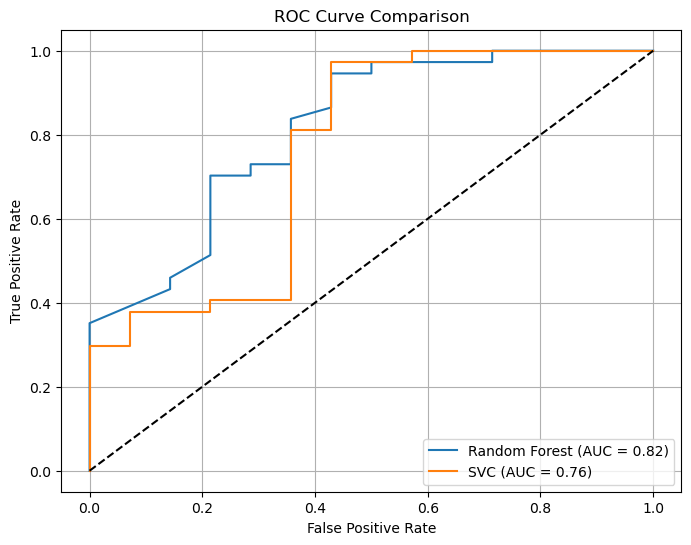

In [ ]:

svc = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svc.fit(X_resampled, y_resampled)

val_preds_svc = svc.predict(X_val)
val_probs_svc = svc.predict_proba(X_val)[:, 1]


plt.figure(figsize=(8,6))

# Random Forest ROC (assuming val_probs_rf is already defined)
fpr_rf, tpr_rf, _ = roc_curve(y_val, val_probs_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

# SVC ROC
fpr_svc, tpr_svc, _ = roc_curve(y_val, val_probs_svc)
roc_auc_svc = auc(fpr_svc, tpr_svc)
plt.plot(fpr_svc, tpr_svc, label=f'SVC (AUC = {roc_auc_svc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid()
plt.show()
